# MM26ML03 — Healthcare Triage Classification (START protocol)

**Track:** Machine Learning · **Problem ID:** MM26ML03 · **Modelling Minds 2.0**

**Goal.** Classify emergency patients into **RED / YELLOW / GREEN / BLACK** while explicitly accounting for the unequal clinical cost of errors (e.g. calling a RED patient GREEN costs 10, the reverse costs 1).

**Approach in one paragraph.** Clean the data and remove shortcuts (`subject_id`), engineer START-inspired physiological features, train four diverse probabilistic classifiers, average them into a soft-voting ensemble, and then — instead of taking the most probable class — pick the class that **minimises expected misclassification cost** under the provided cost matrix (a Bayes-optimal decision rule). Everything is validated with **patient-grouped, stratified cross-validation** plus an untouched hold-out set.

**Notebook map**
1. Setup & data  2. EDA and data-quality checks  3. Feature engineering  4. Cost-sensitive modelling strategy  5. Model comparison (CV)  6. Final evaluation (all required metrics)  7. Robustness & interpretability  8. Test predictions → submission CSV

## 1. Setup & data

In [1]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, log_loss,
                             precision_recall_fscore_support)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)

SEED    = 42
TEAM_ID = "TEAMID"          # <-- replace with your team ID; output file = {TEAM_ID}_MM26ML03.csv
USE_RACE = False            # race has no role in START triage and risks encoding bias (see Section 3)

def find_data_dir():
    for d in [".", "data", "/mnt/user-data/uploads"]:
        if os.path.exists(os.path.join(d, "train_ml03.csv")):
            return d
    raise FileNotFoundError("Place train_ml03.csv and test_pred_ml03.csv next to this notebook.")

DATA_DIR = find_data_dir()
train = pd.read_csv(os.path.join(DATA_DIR, "train_ml03.csv"))
test  = pd.read_csv(os.path.join(DATA_DIR, "test_pred_ml03.csv"))
print(f"train: {train.shape}   test: {test.shape}   (test has no target column: {'start_category' not in test.columns})")
display(train.head(3))

train: (664, 39)   test: (112, 38)   (test has no target column: True)


,subject_id,gender,race,arrival_transport,temperature,heartrate,resprate,o2sat,sbp,dbp,bp_unobtainable,pain_score,pain_assessable,gcs_eye,gcs_verbal,gcs_motor,gcs_total,avpu,avpu_ordinal,follows_commands,consciousness_source,chiefcomplaint,vs_heartrate_min,vs_heartrate_max,vs_heartrate_mean,vs_resprate_min,vs_resprate_max,vs_resprate_mean,vs_sbp_min,vs_sbp_max,vs_sbp_mean,vs_o2sat_min,vs_o2sat_max,vs_o2sat_mean,vs_temperature_max,n_vitalsign_readings,n_diagnoses,n_home_meds,start_category
0,90000355,F,UNKNOWN,AMBULANCE,97.9,112.0,28.0,89.0,93.0,46.0,0,4.0,1.0,4,5,6,15,A,4,1,physiologic_baseline,FRACTURE,102.0,108.0,105.0,26.0,27.0,26.5,82.0,89.0,85.5,86.0,88.0,87.0,97.7,2,3,6,YELLOW
1,90000004,F,UNABLE TO OBTAIN,AMBULANCE,97.0,NaN,0.0,57.0,NaN,NaN,0,NaN,NaN,1,1,1,3,U,1,0,documented_unresponsive,S/P ARREST,0.0,0.0,0.0,0.0,0.0,0.0,45.0,45.0,45.0,NaN,NaN,NaN,96.5,2,2,7,BLACK
2,90000021,M,HISPANIC/LATINO - CUBAN,AMBULANCE,94.1,0.0,0.0,NaN,NaN,NaN,1,NaN,NaN,1,1,1,3,U,1,0,documented_unresponsive,S/P ARREST,8.0,8.0,8.0,0.0,0.0,0.0,24.0,24.0,24.0,NaN,NaN,NaN,96.0,3,1,6,BLACK


### The cost matrix (given — not modified)
Rows = actual class, columns = predicted class. The most expensive mistakes are **RED → GREEN (10)**, and RED → YELLOW / BLACK (5); over-triaging a stable patient costs only 1.

In [2]:
CLASSES      = ["RED", "YELLOW", "GREEN", "BLACK"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
PALETTE      = {"RED": "#d62728", "YELLOW": "#f2c200", "GREEN": "#2ca02c", "BLACK": "#333333"}

COST = np.array([[0, 5, 10, 5],     # actual RED
                 [2, 0,  3, 2],     # actual YELLOW
                 [1, 1,  0, 1],     # actual GREEN
                 [2, 2,  2, 0]])    # actual BLACK
display(pd.DataFrame(COST, index=[f"Actual {c}" for c in CLASSES], columns=[f"Pred {c}" for c in CLASSES]))

def total_cost(y_true, y_pred):
    """Total misclassification cost using the provided matrix."""
    return int(COST[np.asarray(y_true), np.asarray(y_pred)].sum())

y      = train["start_category"].map(CLASS_TO_IDX).to_numpy()
groups = train["subject_id"].to_numpy()        # used ONLY for grouped CV, never as a feature

,Pred RED,Pred YELLOW,Pred GREEN,Pred BLACK
Actual RED,0,5,10,5
Actual YELLOW,2,0,3,2
Actual GREEN,1,1,0,1
Actual BLACK,2,2,2,0


## 2. Exploratory analysis & data-quality checks

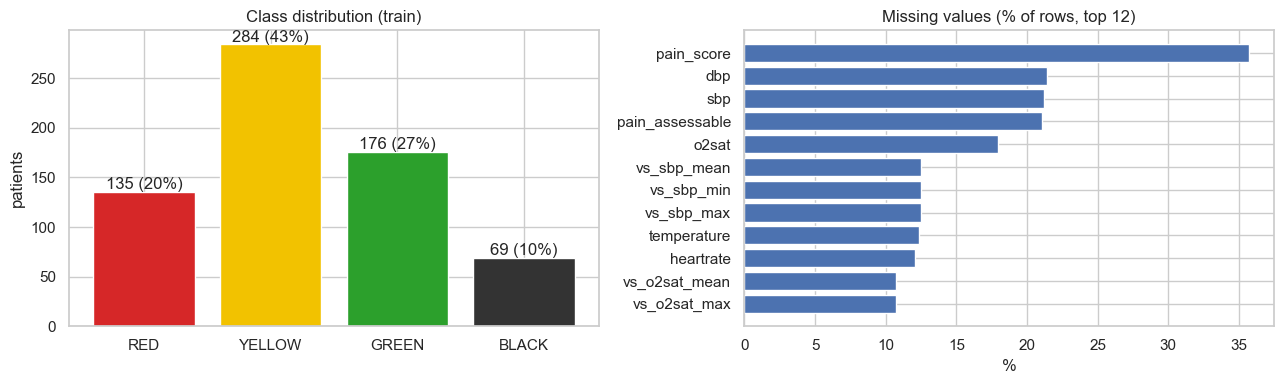

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
counts = train["start_category"].value_counts().reindex(CLASSES)
ax[0].bar(counts.index, counts.values, color=[PALETTE[c] for c in counts.index])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 3, f"{v} ({v/len(train):.0%})", ha="center")
ax[0].set_title("Class distribution (train)"); ax[0].set_ylabel("patients")

miss = train.drop(columns="start_category").isna().mean().sort_values(ascending=False)
miss = miss[miss > 0].head(12)
ax[1].barh(miss.index[::-1], miss.values[::-1] * 100, color="#4c72b0")
ax[1].set_title("Missing values (% of rows, top 12)"); ax[1].set_xlabel("%")
plt.tight_layout(); plt.show()

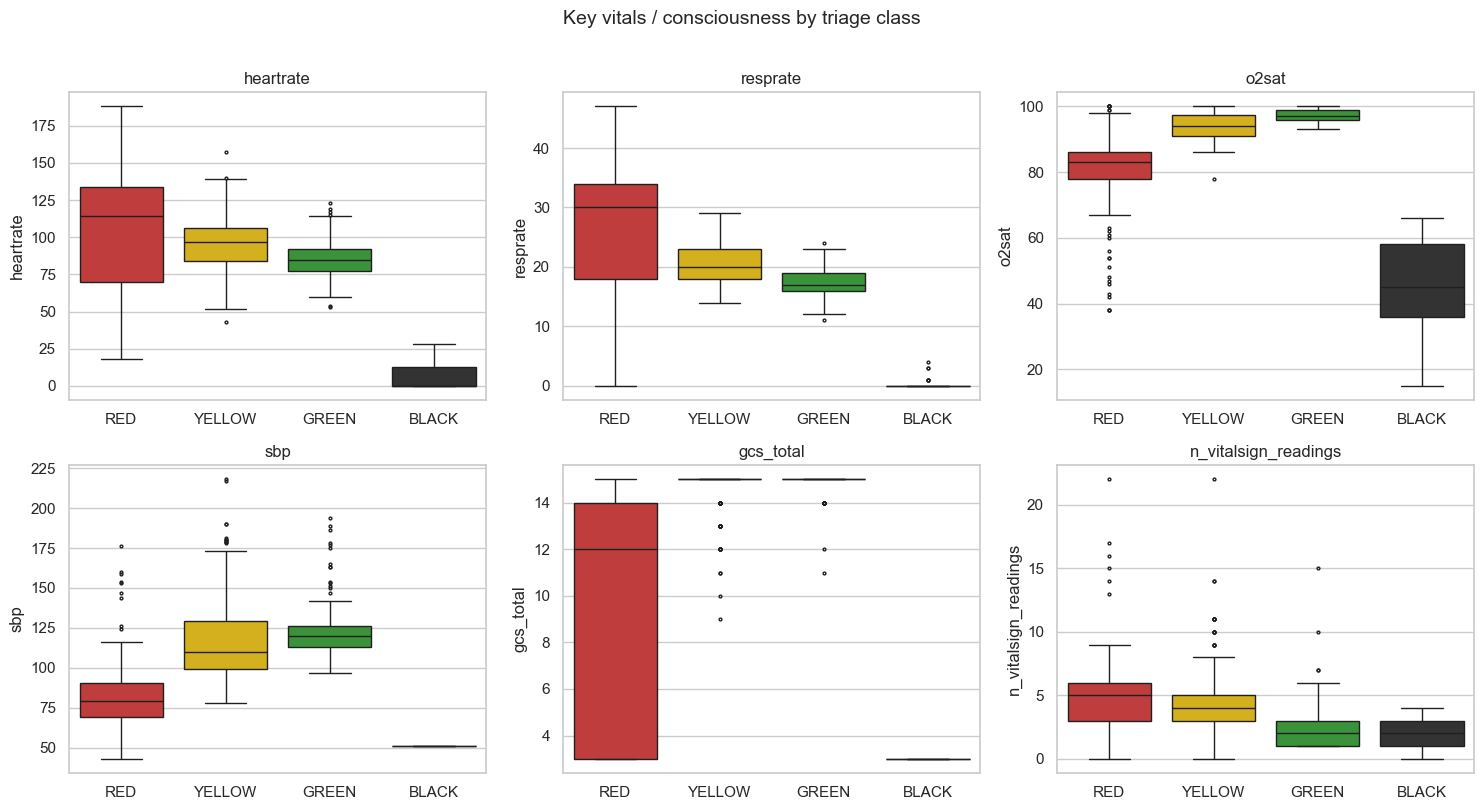

AVPU vs class


start_category,RED,YELLOW,GREEN,BLACK
avpu,,,,
A,44,264,174,0
P,10,3,0,0
U,47,0,0,69
V,34,17,2,0


Arrival transport vs class


start_category,RED,YELLOW,GREEN,BLACK
arrival_transport,,,,
AMBULANCE,123,182,18,66
OTHER,5,10,13,2
UNKNOWN,4,20,9,1
WALK IN,3,72,136,0


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ["heartrate", "resprate", "o2sat", "sbp", "gcs_total", "n_vitalsign_readings"]):
    sns.boxplot(data=train, x="start_category", y=col, order=CLASSES, palette=PALETTE, ax=ax, fliersize=2)
    ax.set_title(col); ax.set_xlabel("")
plt.suptitle("Key vitals / consciousness by triage class", y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

print("AVPU vs class");          display(pd.crosstab(train["avpu"], train["start_category"])[CLASSES])
print("Arrival transport vs class"); display(pd.crosstab(train["arrival_transport"], train["start_category"])[CLASSES])

**Reading the plots.** BLACK patients have essentially no vital signs (HR≈0, RR≈0, very low SpO₂, SBP almost always missing) and are all `avpu = U`. RED patients show tachypnoea, low SpO₂/SBP and impaired GCS; GREEN patients are overwhelmingly `avpu = A`, walk-ins with normal vitals. **Missingness itself is informative** (e.g. 98.6 % of BLACK rows have no SBP), so the model receives explicit missing-value indicators.

### Data-quality checks that shape the modelling

In [5]:
# 1) subject_id as a hidden shortcut ------------------------------------------------------
train["id_range_9e7_plus"] = train["subject_id"] >= 90_000_000
print("Class mix by subject_id range:")
display(pd.crosstab(train["id_range_9e7_plus"], train["start_category"])[CLASSES])

# 2) repeated patients ---------------------------------------------------------------------
rep = train["subject_id"].value_counts()
print(f"\nTrain: {train['subject_id'].nunique()} unique subject_ids for {len(train)} rows; "
      f"{(rep > 1).sum()} ids appear more than once (max {rep.max()} rows for one id).")
print(f"Test : {test['subject_id'].nunique()} unique ids for {len(test)} rows.")
print(f"Overlap of subject_ids between train and test: {len(set(train.subject_id) & set(test.subject_id))}")

# 3) non-integer vital signs ---------------------------------------------------------------
vs_cols = [c for c in train.columns if c.startswith(("vs_heartrate", "vs_resprate", "vs_sbp", "vs_o2sat"))
           and c.endswith(("_min", "_max"))]        # (temperature is naturally decimal, so excluded)
frac = (train[vs_cols].notna() & (train[vs_cols] % 1 != 0)).any(axis=1)
print("\nShare of rows in each class with non-integer min/max vitals:")
display(frac.groupby(train["start_category"]).mean().reindex(CLASSES).round(3).to_frame("share"))
train.drop(columns="id_range_9e7_plus", inplace=True)

Class mix by subject_id range:


start_category,RED,YELLOW,GREEN,BLACK
id_range_9e7_plus,,,,
False,25,124,34,0
True,110,160,142,69



Train: 531 unique subject_ids for 664 rows; 30 ids appear more than once (max 23 rows for one id).
Test : 87 unique ids for 112 rows.
Overlap of subject_ids between train and test: 0

Share of rows in each class with non-integer min/max vitals:


,share
start_category,
RED,0.274
YELLOW,0.000
GREEN,0.000
BLACK,0.594


**Decisions taken from these checks**

* **`subject_id` is dropped as a feature.** All BLACK patients sit in the `9xxxxxxx` ID range, so the ID would be a leaky shortcut that has nothing to do with physiology and would not generalise.
* **Grouped cross-validation.** Some patients contribute several rows; if the same `subject_id` were in both the training and validation folds, scores would be inflated. We therefore use `StratifiedGroupKFold` grouped by `subject_id`. (Train and test IDs do not overlap, so this also mirrors the real train→test situation.)
* **Non-integer vitals occur only in some RED/BLACK rows** — an artefact of how part of the data was produced. We deliberately do *not* build a feature for it; but it is a reason to treat the headline scores as somewhat optimistic compared with real-world triage data.
* `race` is excluded by default (`USE_RACE=False`): it plays no part in START and there is no clinical reason a triage model should use it. Gender is kept as the demographic variable.

## 3. Feature engineering
Features follow the logic of START (ambulatory? breathing / RR > 30? perfusion? can follow commands?) plus haemodynamic indices and chief-complaint groups. Missing vitals are **not** imputed with clinical "guesses": numeric gaps get a median fill *and* a missing-indicator column (fitted inside the CV pipeline, so nothing leaks).

In [6]:
COMPLAINT_GROUPS = {
    "cc_arrest":     r"arrest|code|cpr|obvious death|unresponsive|found down",
    "cc_resp":       r"sob|dyspnea|shortness|resp|breath|hypox|cough",
    "cc_trauma":     r"mvc|trauma|gsw|crush|car vs|pedestrian|assault|intubated|from height",
    "cc_head_neuro": r"head bleed|head injury|\bsdh\b|\bsah\b|\bich\b|\bcva\b|droop|seizure|confusion|altered|letha|syncope|dizz|weakness|numb|diplopia",
    "cc_cardiac":    r"chest|cardiac|nstemi|ekg|palpit|tachycardia|hypotension",
    "cc_bleed":      r"bleed|hemat|brbpr|coffee|anemia|\binr\b",
    "cc_infect":     r"sepsis|fever|infect|cellulitis|neutrop|ulcer|\bili\b",
    "cc_abdominal":  r"abd|epigastric|rlq|luq|suprapubic",
    "cc_fall_fx":    r"fall|fracture|\bfx\b|ankle",
    "cc_minor":      r"headache|laceration|rash|back pain|wound|pain",
    "cc_psych_tox":  r"overdose|etoh|\bsi\b|psych|depress|hallucin",
    "cc_transfer":   r"transfer",
}

def engineer(df):
    """Raw dataframe -> model-ready feature dataframe (no target, no subject_id)."""
    drop = ["subject_id", "start_category"] + ([] if USE_RACE else ["race"])
    X = df.drop(columns=drop, errors="ignore").copy()

    # chief complaint -> multi-hot keyword groups (the raw text is kept too; rare values are pooled later)
    cc = df["chiefcomplaint"].str.lower()
    for name, pattern in COMPLAINT_GROUPS.items():
        X[name] = cc.str.contains(pattern, regex=True).astype(int)

    # haemodynamics
    sbp = X["sbp"].where(X["sbp"] > 0)
    X["shock_index"]    = X["heartrate"] / sbp
    X["map"]            = (X["sbp"] + 2 * X["dbp"]) / 3
    X["pulse_pressure"] = X["sbp"] - X["dbp"]

    # variability over the stay (instability / deterioration)
    for v in ["heartrate", "resprate", "sbp", "o2sat"]:
        X[f"{v}_range"] = X[f"vs_{v}_max"] - X[f"vs_{v}_min"]

    # START-style rule flags
    X["rr_gt30"]     = (X["resprate"] > 30).astype(int)
    X["rr_zero"]     = (X["resprate"] == 0).astype(int)          # not breathing
    X["hr_gt120"]    = (X["heartrate"] > 120).astype(int)         # perfusion proxy
    X["sbp_lt90"]    = (X["sbp"] < 90).astype(int)
    X["o2_lt90"]     = (X["o2sat"] < 90).astype(int)
    X["gcs_le8"]     = (X["gcs_total"] <= 8).astype(int)
    X["no_commands"] = 1 - X["follows_commands"]                  # cannot follow simple commands
    X["n_core_missing"] = X[["temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp"]].isna().sum(axis=1)
    return X

X_all  = engineer(train)
X_test = engineer(test)
assert list(X_all.columns) == list(X_test.columns)

CAT_COLS = [c for c in X_all.columns if not pd.api.types.is_numeric_dtype(X_all[c])]
NUM_COLS = [c for c in X_all.columns if c not in CAT_COLS]
print(f"{X_all.shape[1]} model inputs  ->  {len(NUM_COLS)} numeric, {len(CAT_COLS)} categorical: {CAT_COLS}")

63 model inputs  ->  58 numeric, 5 categorical: ['gender', 'arrival_transport', 'avpu', 'consciousness_source', 'chiefcomplaint']


## 4. Cost-sensitive modelling strategy
Two complementary ways to make the model care about the cost matrix — we test both, separately and combined:

1. **Cost-aware training (class weights).** Each class is weighted by its average *cost of being missed* (mean of the off-diagonal entries of its row, normalised). RED gets the largest weight, GREEN the smallest.
2. **Cost-aware decision rule (minimum expected cost, MEC).** Given class probabilities $p(i\mid x)$, predict
$$\hat y(x)=\arg\min_{j}\ \sum_i p(i\mid x)\,C[i,j]$$
instead of $\arg\max_i p(i\mid x)$. This is the Bayes-optimal decision for a known cost matrix and keeps the *probabilities* honest (they are still the model's estimates of class membership).

Base learners are deliberately diverse: a linear model (logistic regression), two bagged tree ensembles (Random Forest, Extra Trees) and gradient boosting. The final classifier soft-votes (averages) their probabilities.

In [7]:
# class weights from the cost matrix: mean off-diagonal cost of each row, rescaled to average 1
row_cost = COST.sum(axis=1) / (COST.shape[1] - 1)
CLASS_W  = {i: float(w) for i, w in enumerate(row_cost / row_cost.mean())}
print("Cost-derived class weights:", {CLASSES[i]: round(w, 2) for i, w in CLASS_W.items()})

def min_expected_cost_decision(proba):
    """argmin_j  sum_i p_i * C[i, j]"""
    return (np.asarray(proba) @ COST).argmin(axis=1)

def make_preprocessor(scale=False):
    num_steps = [("impute", SimpleImputer(strategy="median", add_indicator=True))]   # + missing-value flags
    if scale:
        num_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=5), CAT_COLS),   # rare categories pooled
    ])

def make_models(weighted=False):
    """Fresh (unfitted) pipelines. weighted=True adds cost-derived class weights."""
    cw = CLASS_W if weighted else None
    return {
        "LogReg":     Pipeline([("pre", make_preprocessor(scale=True)),
                                ("clf", LogisticRegression(C=0.5, max_iter=5000, class_weight=cw))]),
        "RandForest": Pipeline([("pre", make_preprocessor()),
                                ("clf", RandomForestClassifier(500, min_samples_leaf=2, class_weight=cw,
                                                               n_jobs=-1, random_state=SEED))]),
        "ExtraTrees": Pipeline([("pre", make_preprocessor()),
                                ("clf", ExtraTreesClassifier(500, min_samples_leaf=2, class_weight=cw,
                                                             n_jobs=-1, random_state=SEED))]),
        "HistGB":     Pipeline([("pre", make_preprocessor()),
                                ("clf", HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200,
                                                                       l2_regularization=1.0, class_weight=cw,
                                                                       random_state=SEED))]),
    }

class SoftVoteEnsemble(BaseEstimator, ClassifierMixin):
    """Average of the four pipelines' probabilities. predict() applies the MEC rule by default."""
    def __init__(self, weighted=False, decision="mec"):
        self.weighted, self.decision = weighted, decision
    def fit(self, X, y):
        self.models_  = [m.fit(X, y) for m in make_models(self.weighted).values()]
        self.classes_ = np.arange(len(CLASSES))
        return self
    def predict_proba(self, X):
        return np.mean([m.predict_proba(X) for m in self.models_], axis=0)
    def predict(self, X):
        p = self.predict_proba(X)
        return min_expected_cost_decision(p) if self.decision == "mec" else p.argmax(axis=1)

Cost-derived class weights: {'RED': 2.22, 'YELLOW': 0.78, 'GREEN': 0.33, 'BLACK': 0.67}


## 5. Validation design & model comparison
* **Hold-out (~20 %)**: one stratified, patient-grouped fold that is *never* used for any choice. It is only used for the final report in Section 6.
* **Development set (~80 %)**: used for 5-fold `StratifiedGroupKFold` cross-validation to compare models and strategies. All predictions below are **out-of-fold**.

In [8]:
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
dev_idx, hold_idx = next(splitter.split(X_all, y, groups))

X_dev,  y_dev,  g_dev  = X_all.iloc[dev_idx],  y[dev_idx],  groups[dev_idx]
X_hold, y_hold         = X_all.iloc[hold_idx], y[hold_idx]

assert not set(groups[dev_idx]) & set(groups[hold_idx]), "patient leaked across dev/hold-out"
print(f"dev: {len(dev_idx)} rows   hold-out: {len(hold_idx)} rows   (no shared patients)")
print(pd.DataFrame({"dev": np.bincount(y_dev, minlength=4), "hold-out": np.bincount(y_hold, minlength=4)}, index=CLASSES).T)

def oof_proba(estimator, X, y_, g, seed=SEED, n_splits=5):
    """Out-of-fold class probabilities with patient-grouped, stratified folds."""
    P = np.zeros((len(y_), len(CLASSES)))
    for a, b in StratifiedGroupKFold(n_splits, shuffle=True, random_state=seed).split(X, y_, g):
        P[b] = clone(estimator).fit(X.iloc[a], y_[a]).predict_proba(X.iloc[b])
    return P

dev: 564 rows   hold-out: 100 rows   (no shared patients)
          RED  YELLOW  GREEN  BLACK
dev       112     249    151     52
hold-out   23      35     25     17


In [9]:
# Out-of-fold probabilities for every model, with and without cost-weighted training
oof = {}
for weighted in (False, True):
    for name, model in make_models(weighted).items():
        oof[(name, weighted)] = oof_proba(model, X_dev, y_dev, g_dev)
    oof[("Ensemble", weighted)] = np.mean([oof[(n, weighted)] for n in make_models()], axis=0)
print("done:", len(oof), "sets of out-of-fold probabilities")

done: 10 sets of out-of-fold probabilities


In [10]:
rows = []
for (name, weighted), P in oof.items():
    for decision, pred in (("argmax", P.argmax(1)), ("MEC", min_expected_cost_decision(P))):
        cm = confusion_matrix(y_dev, pred, labels=range(4))
        rows.append({"Model": name,
                     "Training": "cost-weighted" if weighted else "plain",
                     "Decision": decision,
                     "Accuracy": accuracy_score(y_dev, pred),
                     "Macro-F1": f1_score(y_dev, pred, average="macro"),
                     "Total cost": total_cost(y_dev, pred),
                     "RED recall": cm[0, 0] / cm[0].sum(),
                     "RED→GREEN": cm[0, 2]})
cv_table = pd.DataFrame(rows).sort_values("Total cost").reset_index(drop=True)
display(cv_table.style.format({"Accuracy": "{:.3f}", "Macro-F1": "{:.3f}", "RED recall": "{:.3f}"})
        .background_gradient(subset=["Total cost"], cmap="RdYlGn_r"))

,Model,Training,Decision,Accuracy,Macro-F1,Total cost,RED recall,RED→GREEN
0,LogReg,cost-weighted,MEC,0.892,0.906,121,0.902,0
1,Ensemble,plain,MEC,0.897,0.911,122,0.893,0
2,Ensemble,cost-weighted,MEC,0.879,0.896,127,0.902,0
3,LogReg,cost-weighted,argmax,0.911,0.922,132,0.866,0
4,ExtraTrees,plain,MEC,0.879,0.890,137,0.884,0
5,HistGB,cost-weighted,MEC,0.899,0.917,141,0.893,0
6,Ensemble,cost-weighted,argmax,0.913,0.926,142,0.848,0
7,LogReg,plain,MEC,0.894,0.908,144,0.875,0
8,RandForest,plain,MEC,0.840,0.848,151,0.902,0
9,ExtraTrees,cost-weighted,argmax,0.913,0.914,153,0.821,0


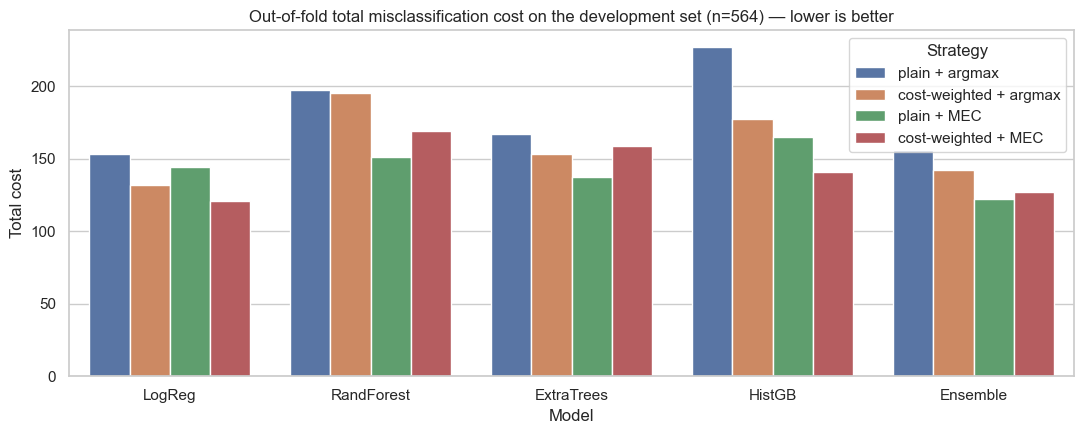

Ensemble cost  plain+argmax = 156  |  cost-weighted+argmax = 142  |  plain+MEC = 122  |  cost-weighted+MEC = 127
MEC decision rule reduces the ensemble's cost by 22% vs. plain argmax.


In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
plot_df = cv_table.assign(Strategy=cv_table["Training"] + " + " + cv_table["Decision"])
sns.barplot(data=plot_df, x="Model", y="Total cost", hue="Strategy", ax=ax,
            order=["LogReg", "RandForest", "ExtraTrees", "HistGB", "Ensemble"],
            hue_order=["plain + argmax", "cost-weighted + argmax", "plain + MEC", "cost-weighted + MEC"])
ax.set_title(f"Out-of-fold total misclassification cost on the development set (n={len(y_dev)}) — lower is better")
plt.tight_layout(); plt.show()

# how much does each mechanism buy us for the ensemble?
def c(training, decision): return int(cv_table.query("Model=='Ensemble' and Training==@training and Decision==@decision")["Total cost"].iloc[0])
base = c("plain", "argmax")
print(f"Ensemble cost  plain+argmax = {base}  |  cost-weighted+argmax = {c('cost-weighted','argmax')}  "
      f"|  plain+MEC = {c('plain','MEC')}  |  cost-weighted+MEC = {c('cost-weighted','MEC')}")
print(f"MEC decision rule reduces the ensemble's cost by {100*(1-c('plain','MEC')/base):.0f}% vs. plain argmax.")

**Take-aways from the comparison**
1. The MEC decision rule lowers total cost for every plain-trained model, and the plain-trained **ensemble + MEC** has the lowest cost of all 20 combinations. For the ensemble, accuracy is essentially unchanged — MEC mostly turns uncertain cases into *cautious* ones rather than making the model worse.
2. Cost-weighted training on its own also reduces cost (argmax decisions), but stacking it with MEC brings no further gain: the cost is effectively counted twice and predictions get pushed too far towards RED. Single Random Forest / Extra Trees models lose accuracy under MEC, which suggests their raw probabilities are over-dispersed; averaging with the other learners tempers this.
3. The soft-voting ensemble is more stable than any single learner, so the final model is **plain-trained ensemble + MEC decision rule**. This was chosen on design grounds (probabilistic model + Bayes-optimal decision for a known cost matrix) and is confirmed — not discovered — by the table.

## 6. Final evaluation — all required metrics
### 6a. Untouched hold-out set
The ensemble is fitted on the development set only and scored once on the hold-out patients.

=== HOLD-OUT · ensemble + MEC  (n=100) ===


,Accuracy,Macro-F1,Weighted-F1,Total cost,Avg cost / patient
value,0.96,0.965,0.959,4.0,0.04


,Precision,Recall,F1-score,Support
RED,1.000,1.00,1.000,23
YELLOW,0.897,1.00,0.946,35
GREEN,1.000,0.84,0.913,25
BLACK,1.000,1.00,1.000,17


,Pred RED,Pred YELLOW,Pred GREEN,Pred BLACK
Actual RED,23,0,0,0
Actual YELLOW,0,35,0,0
Actual GREEN,0,4,21,0
Actual BLACK,0,0,0,17


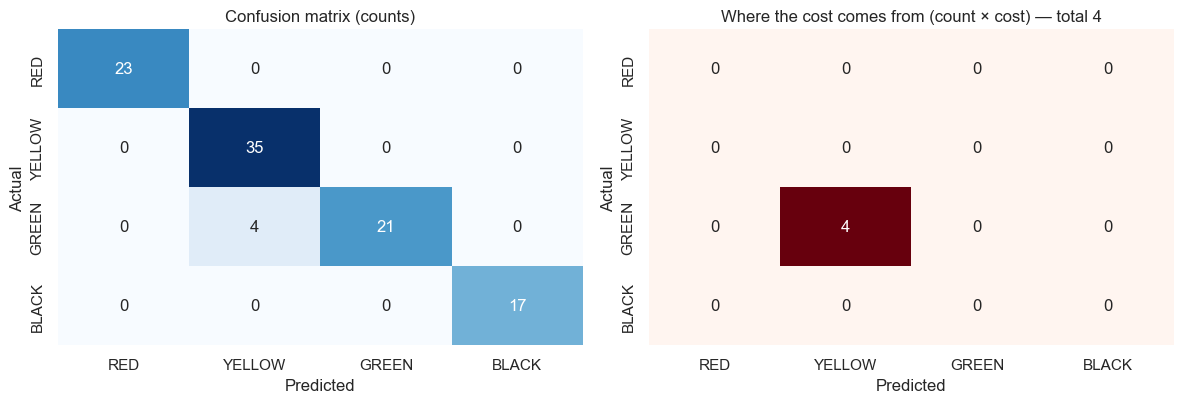

In [12]:
def full_report(y_true, y_pred, title):
    """Accuracy, per-class P/R/F1, macro/weighted F1, confusion matrix, total cost."""
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=range(4), zero_division=0)
    per_class = pd.DataFrame({"Precision": p, "Recall": r, "F1-score": f, "Support": s}, index=CLASSES)
    summary = pd.Series({
        "Accuracy":      accuracy_score(y_true, y_pred),
        "Macro-F1":      f1_score(y_true, y_pred, average="macro"),
        "Weighted-F1":   f1_score(y_true, y_pred, average="weighted"),
        "Total cost":    total_cost(y_true, y_pred),
        "Avg cost / patient": total_cost(y_true, y_pred) / len(y_true),
    })
    cm = confusion_matrix(y_true, y_pred, labels=range(4))

    print(f"=== {title}  (n={len(y_true)}) ===")
    display(summary.to_frame("value").T.round(3))
    display(per_class.round(3))
    display(pd.DataFrame(cm, index=[f"Actual {c}" for c in CLASSES], columns=[f"Pred {c}" for c in CLASSES]))

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[0], xticklabels=CLASSES, yticklabels=CLASSES)
    ax[0].set_title("Confusion matrix (counts)"); ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
    sns.heatmap(cm * COST, annot=True, fmt="d", cmap="Reds", cbar=False, ax=ax[1], xticklabels=CLASSES, yticklabels=CLASSES)
    ax[1].set_title(f"Where the cost comes from (count × cost) — total {int(summary['Total cost'])}")
    ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
    plt.tight_layout(); plt.show()
    return summary, per_class, cm

dev_model  = SoftVoteEnsemble(weighted=False).fit(X_dev, y_dev)
hold_proba = dev_model.predict_proba(X_hold)
hold_pred  = min_expected_cost_decision(hold_proba)                       # final decision rule
hold_summary, hold_per_class, hold_cm = full_report(y_hold, hold_pred, "HOLD-OUT · ensemble + MEC")

In [13]:
# for reference: same probabilities, plain argmax decision
hold_argmax = hold_proba.argmax(1)
print(f"Hold-out reference — argmax: accuracy {accuracy_score(y_hold, hold_argmax):.3f}, cost {total_cost(y_hold, hold_argmax)}"
      f"   |   MEC: accuracy {accuracy_score(y_hold, hold_pred):.3f}, cost {total_cost(y_hold, hold_pred)}")

Hold-out reference — argmax: accuracy 0.990, cost 5   |   MEC: accuracy 0.960, cost 4


### 6b. Out-of-fold results over the *entire* training set (more stable, n = 664)
The hold-out is small (~130 patients), so we also report grouped-CV out-of-fold predictions for **all** training rows, repeated over 3 different fold assignments to show how much the numbers move.

In [14]:
SEEDS = [SEED, 7, 2024]
oof_full = {s: oof_proba(SoftVoteEnsemble(weighted=False), X_all, y, groups, seed=s) for s in SEEDS}

rep_rows = []
for s, P in oof_full.items():
    for decision, pred in (("argmax", P.argmax(1)), ("MEC", min_expected_cost_decision(P))):
        rep_rows.append({"seed": s, "Decision": decision, "Accuracy": accuracy_score(y, pred),
                         "Macro-F1": f1_score(y, pred, average="macro"), "Total cost": total_cost(y, pred)})
rep_df = pd.DataFrame(rep_rows)
display(rep_df.groupby("Decision")[["Accuracy", "Macro-F1", "Total cost"]].agg(["mean", "std"]).round(3))
pv = rep_df.pivot(index="seed", columns="Decision", values="Total cost")
print("MEC beats argmax on total cost in", int((pv["MEC"] < pv["argmax"]).sum()), "of", len(SEEDS), "fold assignments.")

Accuracy        Macro-F1        Total cost       
             mean    std     mean    std       mean    std
Decision                                                  
MEC         0.914  0.008    0.925  0.007    125.667  11.93
argmax      0.923  0.003    0.933  0.002    172.000   7.00

MEC beats argmax on total cost in 3 of 3 fold assignments.


=== OUT-OF-FOLD, full training set · ensemble + MEC  (n=664) ===


,Accuracy,Macro-F1,Weighted-F1,Total cost,Avg cost / patient
value,0.916,0.927,0.916,122.0,0.184


,Precision,Recall,F1-score,Support
RED,0.911,0.911,0.911,135
YELLOW,0.869,0.954,0.909,284
GREEN,0.980,0.835,0.902,176
BLACK,1.000,0.971,0.985,69


,Pred RED,Pred YELLOW,Pred GREEN,Pred BLACK
Actual RED,123,12,0,0
Actual YELLOW,10,271,3,0
Actual GREEN,0,29,147,0
Actual BLACK,2,0,0,67


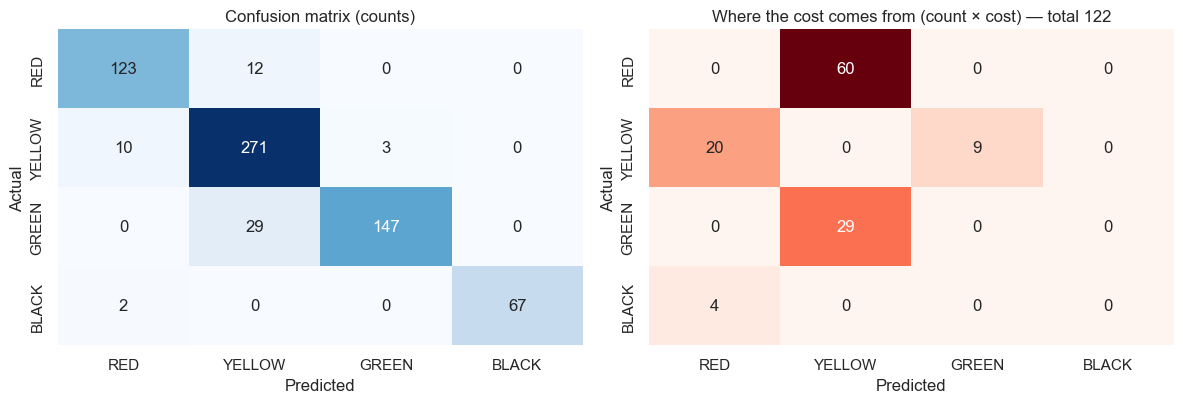

In [15]:
P_oof = oof_full[SEED]
oof_pred = min_expected_cost_decision(P_oof)
oof_summary, oof_per_class, oof_cm = full_report(y, oof_pred, "OUT-OF-FOLD, full training set · ensemble + MEC")

**Reading the confusion matrix.** In our run the remaining errors are borderline RED↔YELLOW and GREEN→YELLOW cases, BLACK is almost perfectly separated, and **no RED patient was labelled GREEN** (the 10-point error). Because of the MEC rule, the model prefers to over-triage (GREEN→YELLOW costs only 1) rather than risk a serious under-triage — which is why GREEN has the lowest recall but the highest precision.

## 7. Interpretability — which inputs drive the predictions?

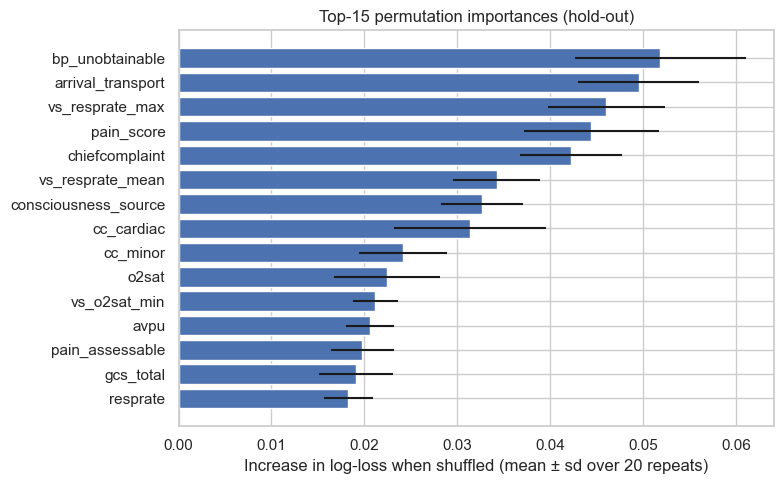

In [16]:
# Permutation importance on the hold-out set: how much does the ensemble's log-loss (probability quality)
# get worse when one input column is shuffled? Higher = the model leans on it more.
def neg_logloss(est, X, y_):
    return -log_loss(y_, est.predict_proba(X), labels=range(len(CLASSES)))

perm = permutation_importance(dev_model, X_hold, y_hold, scoring=neg_logloss, n_repeats=20,
                              random_state=SEED, n_jobs=1)
imp = (pd.DataFrame({"feature": X_hold.columns, "delta": perm.importances_mean, "std": perm.importances_std})
         .sort_values("delta", ascending=False).head(15))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp["feature"][::-1], imp["delta"][::-1], xerr=imp["std"][::-1], color="#4c72b0")
ax.set_xlabel("Increase in log-loss when shuffled (mean ± sd over 20 repeats)")
ax.set_title("Top-15 permutation importances (hold-out)")
plt.tight_layout(); plt.show()

## 8. Predictions for the test patients → submission file
The final model is refit on **all 664 labelled patients** and applied to the 112 test patients. The output keeps the original test ordering and contains the predicted category (from the MEC rule) and the four class probabilities.

> The *Predicted Triage* column is the cost-minimising decision, so in a small number of borderline cases it can differ from the class with the single highest probability — that is intentional (RED is chosen more readily than its raw probability alone would justify).

In [17]:
final_model = SoftVoteEnsemble(weighted=False).fit(X_all, y)
proba_test  = final_model.predict_proba(X_test)
pred_test   = min_expected_cost_decision(proba_test)

submission = pd.DataFrame({
    "Patient ID":       test["subject_id"].to_numpy(),
    "Predicted Triage": [CLASSES[i] for i in pred_test],
    **{f"{c} Probability": proba_test[:, i].round(4) for i, c in enumerate(CLASSES)},
})

# sanity checks required by the brief
assert len(submission) == len(test) == 112
assert (submission["Patient ID"].to_numpy() == test["subject_id"].to_numpy()).all(), "ordering must be preserved"
assert submission.notna().all().all()
assert np.allclose(submission[[f"{c} Probability" for c in CLASSES]].sum(axis=1), 1, atol=1e-3)

OUT_PATH = f"{TEAM_ID}_MM26ML03.csv"
submission.to_csv(OUT_PATH, index=False)
print(f"saved -> {OUT_PATH}")
display(submission.head(8))

print("\nPredicted class counts (test):"); print(submission["Predicted Triage"].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())
print(f"\nRows where cost-aware decision differs from the most probable class: {(pred_test != proba_test.argmax(1)).sum()} of {len(test)}")

saved -> TEAMID_MM26ML03.csv


,Patient ID,Predicted Triage,RED Probability,YELLOW Probability,GREEN Probability,BLACK Probability
0,90000431,BLACK,0.1766,0.0052,0.0004,0.8178
1,90000438,BLACK,0.0170,0.0000,0.0000,0.9829
2,90000445,BLACK,0.0425,0.0018,0.0002,0.9555
3,90000457,BLACK,0.0107,0.0002,0.0000,0.9891
4,90000460,BLACK,0.0442,0.0004,0.0000,0.9555
5,90000461,BLACK,0.0114,0.0028,0.0000,0.9857
6,90000481,BLACK,0.0068,0.0000,0.0001,0.9930
7,90000489,BLACK,0.0062,0.0001,0.0000,0.9937



Predicted class counts (test):
Predicted Triage
RED       22
YELLOW    50
GREEN     29
BLACK     11

Rows where cost-aware decision differs from the most probable class: 10 of 112


In [18]:
# sanity check: predictions vs. an independent clinical signal (AVPU) in the test set
display(pd.crosstab(test["avpu"], submission["Predicted Triage"]).reindex(columns=CLASSES, fill_value=0))

Predicted Triage,RED,YELLOW,GREEN,BLACK
avpu,,,,
A,5,48,29,0
P,3,0,0,0
U,8,0,0,11
V,6,2,0,0


## 9. Summary, assumptions & limitations
**What was done**
* Removed `subject_id` (shortcut) and `race`; engineered START-style flags, haemodynamic indices, vital-sign variability and chief-complaint groups; explicit missing-value indicators.
* Soft-voting ensemble of Logistic Regression, Random Forest, Extra Trees and Gradient Boosting.
* Cost handled with the **provided** matrix via a minimum-expected-cost decision rule (and cost-derived class weights evaluated as an alternative).
* Patient-grouped stratified CV + an untouched hold-out; all required metrics reported (accuracy, per-class precision/recall/F1, macro/weighted F1, confusion matrix, total cost).

**Caveats**
* Small dataset (664 rows) → metric estimates carry noticeable variance (see the spread across CV seeds).
* MEC relies on reasonably calibrated probabilities; probability calibration (e.g. Platt/isotonic) is a natural next step with more data.
* Some inputs (`n_diagnoses`, `n_home_meds`, `consciousness_source = documented_*`) come from the wider ED record and may not be available at the moment of field triage; a deployed system should be re-validated with only point-of-care inputs.
* Part of the data has non-integer vital signs concentrated in RED/BLACK rows; real-world performance is likely lower than the scores shown here.
* This is a decision-support prototype for a competition, not a validated clinical tool.